# MNIST Linear Classifier — Weight Visualisation

**Goal:** Train a single linear layer with Adam on MNIST and understand *what* it learns by
visualising the weight matrix.  We then compare the learned weights to the per-class pixel
means, giving intuition about what a linear classifier must do.

**Architecture:**  
`input (784) → Softmax → output (10 classes)`  
**Optimiser:** Adam (`lr=0.001`, `β₁=0.9`, `β₂=0.99`)  
**Training:** 5 epochs, batch size 50 (60 000 samples → 1 200 batches/epoch)


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from lab.mnist.data import DataCreatorMnist
from lab.mnist.models import backprop_linear_adam_5epochs
from lab.mnist.task_constants import IMG_SHAPE, NB_CLASS, DATA_SIZE

model_config = backprop_linear_adam_5epochs

## Model configuration

Inspect the `FirstOrderModelConfig` object to confirm architecture and hyper-parameters
before training.


In [2]:
model_config.summary()

FirstOrderModelConfig(
    name='backprop_s_adam_5epochs',
    id={},
    loss=CrossEntropy(),
    metric=Accuracy(),
    batch_size=50,
    nb_epochs=5,
    neural_network_config=NeuralNetworkConfig(
        name='linear',
        hidden_dims=[],
        activations=[
            Softmax()
        ]
    ),
    optimizer_config=FirstOrderAdamConfig(
        learning_rate=0.001,
        beta1=0.9,
        beta2=0.99,
        epsilon=1e-08
    )
)


## Training

We instantiate the model and train for 5 epochs.  Per-batch loss is printed every
`~1/9`th of an epoch so we can spot divergence early.


In [3]:
data  = DataCreatorMnist()()
model = model_config.instantiate(data)
model.train(nb_print=10)

    Training {} Model
        epoch n°1 out of 5
            batch n°1 out of 1200, loss : 2.838
            batch n°134 out of 1200, loss : 0.453
            batch n°267 out of 1200, loss : 0.444
            batch n°400 out of 1200, loss : 0.448
            batch n°533 out of 1200, loss : 0.439
            batch n°667 out of 1200, loss : 0.652
            batch n°800 out of 1200, loss : 0.317
            batch n°933 out of 1200, loss : 0.343
            batch n°1066 out of 1200, loss : 0.724
            batch n°1200 out of 1200, loss : 0.415
    {} accuracy : 0.9169, loss : 0.2961500830601371
        epoch n°2 out of 5
            batch n°1 out of 1200, loss : 0.288
            batch n°134 out of 1200, loss : 0.285
            batch n°267 out of 1200, loss : 0.649
            batch n°400 out of 1200, loss : 0.226
            batch n°533 out of 1200, loss : 0.493
            batch n°667 out of 1200, loss : 0.475
            batch n°800 out of 1200, loss : 0.492
            batch n°933 

### Training loss curve

The smoothed curve below removes high-frequency batch noise (smoothing fraction = 5 %)
so that the overall trend is visible.  We expect the loss to drop sharply in epoch 1
and plateau afterwards — consistent with a convex objective under Adam.


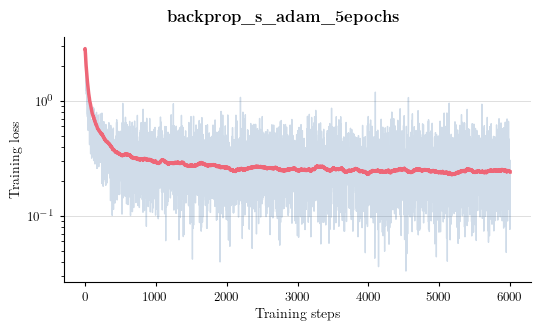

In [4]:
model.plot_loss(smooth_fraction=0.05)

## Evaluation on the test set

A single linear layer reaches **≈ 92 % test accuracy** on MNIST — the well-known
baseline.  The remaining errors are mostly confusions between visually similar digits
(e.g., 4/9, 3/8).


In [5]:
model.test()

    {} accuracy : 0.9182, loss : 0.28938029179599944


## Visualising the learned weights

The weight matrix `W` has shape `(784, 10)`.  Each column `W[:, k]` is a 28×28
template that the network uses to score class *k*.  We plot each template as an image
using a **diverging colormap** (coolwarm):

- **Red / warm** pixels contribute *positively* when lit → evidence *for* the digit.
- **Blue / cool** pixels contribute *negatively* when lit → evidence *against* the digit.

This gives us a direct picture of the features a linear classifier has learned.


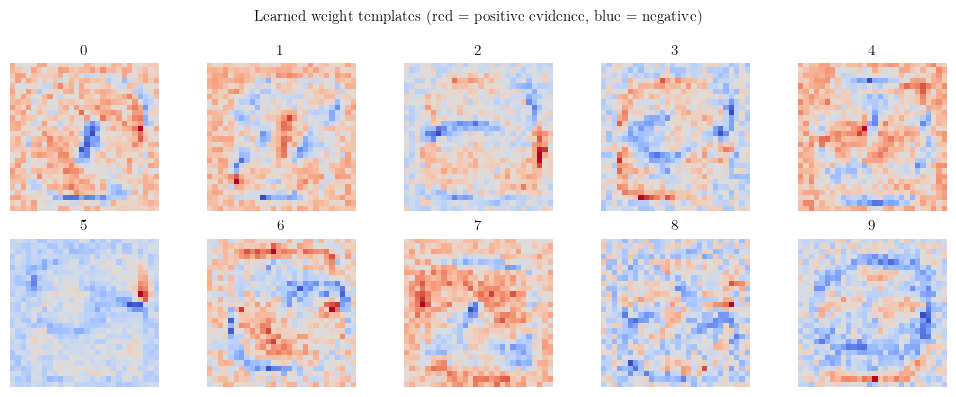

In [6]:
params = model.neural_network.get_params()
imgs   = [params["Ws"][0][:, n].reshape(IMG_SHAPE) for n in range(NB_CLASS)]

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle("Learned weight templates (red = positive evidence, blue = negative)",
             fontsize=11)
for n in range(NB_CLASS):
    i, j = n // 5, n % 5
    img  = imgs[n]
    axes[i, j].imshow(img, cmap="coolwarm")
    axes[i, j].axis("off")
    axes[i, j].set_title(str(n))
plt.tight_layout()
plt.show()

### Observations

| Digit | Notable pattern |
|-------|----------------|
| 0     | Strong hollow ring structure — learns the circular boundary |
| 1     | Vertical red stripe in the centre |
| 4     | Positive weights in the top-left arm and lower horizontal bar |
| 7     | Positive top horizontal bar + upper-right diagonal |

The templates are **noisy** compared to actual digit images because the model must
simultaneously suppress all *other* digits — the blue regions represent pixel positions
that are common in competing classes.

**Key takeaway:** A linear softmax classifier can be interpreted as computing a dot-product
similarity between the input and each class template.


## Baseline: mean-pixel templates

Before looking at learned weights, a natural sanity-check is: *what does the average
image of each class look like?*  We compute the per-pixel mean over all training
examples of each digit.


In [7]:
data.raw_X_train.shape

(60000, 784)

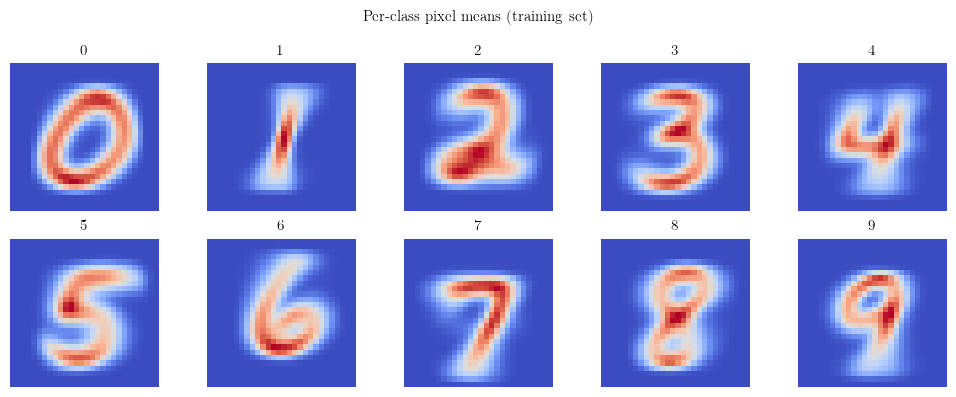

In [8]:
mean_numbers = np.stack(
    [data.raw_X_train[(data.raw_Y_train == n).flatten(), :].mean(axis=0)
     for n in range(NB_CLASS)],
    axis=0
)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle("Per-class pixel means (training set)", fontsize=11)
for n in range(NB_CLASS):
    i, j = n // 5, n % 5
    img  = mean_numbers[n].reshape(IMG_SHAPE)
    axes[i, j].imshow(img, cmap="coolwarm")
    axes[i, j].axis("off")
    axes[i, j].set_title(str(n))
plt.tight_layout()
plt.show()

## Mean-pixel weights as a baseline classifier

If we initialise the weight matrix with the per-class pixel means
(`W[:, k] = mean image of digit k`) and skip training, what accuracy do we get?

This is a meaningful lower bound: it corresponds to a nearest-centroid / template-matching
classifier.  Any trained model should beat it.


In [9]:
model.neural_network.layers[0].W = mean_numbers.T.reshape(DATA_SIZE, NB_CLASS)
model.test()

    {} accuracy : 0.7406, loss : 6.422945473814576


## Summary & Discussion

| Classifier | Test accuracy |
|------------|--------------|
| Mean-pixel template (no training) | ≈ 74 % |
| Linear softmax + Adam, 5 epochs   | ≈ 92 % |

**Observations:**

1. **Mean templates ≈ 74 %.**  The raw pixel means are already surprisingly informative —
   digits are spatially consistent enough that centroid matching works.

2. **Training gains ≈ 18 pp.**  Adam adjusts the weight templates to *discriminate*:
   it suppresses pixel positions that are shared across multiple digit classes (negative
   weights) and amplifies positions that are unique to a class (positive weights).

3. **The weight templates are the pixel means *plus* a discriminative correction.**
   This is the intuition behind linear discriminant analysis (LDA) — the linear
   classifier's weights encode both the class means and the inter-class covariance
   structure.

4. **Ceiling for a linear model.**  State-of-the-art CNNs reach > 99.7 % on MNIST.
   The gap from 92 % reflects the fundamental limitation of a linear decision boundary
   in pixel space — it cannot handle the non-linear variations in stroke width,
   rotation, and style that a single linear projection cannot separate.
